# 01 - Data Exploration

This notebook explores the Severstal Steel Defect Detection dataset.

The objective is to understand the dataset structure before building a CNN-based defect classification model.

Main steps:
- Load the training annotations
- Inspect the available image folders
- Analyze defect classes
- Create a binary label for defect / no defect classification
- Visualize example steel surface images

In [4]:
# Basic libraries
import pandas as pd
import numpy as np

# For file paths
from pathlib import Path

# For visualization
import matplotlib.pyplot as plt

# For image loading
import cv2

In [7]:
# Main project folder
PROJECT_ROOT = Path.cwd().parent

# Raw dataset folder
DATA_DIR = PROJECT_ROOT / "data" / "raw"

# Dataset files and folders
TRAIN_CSV_PATH = DATA_DIR / "train.csv"
TRAIN_IMAGES_DIR = DATA_DIR / "train_images"
TEST_IMAGES_DIR = DATA_DIR / "test_images"

# Quick path checks
print("Project root:", PROJECT_ROOT)
print("Train CSV exists:", TRAIN_CSV_PATH.exists())
print("Train images exist:", TRAIN_IMAGES_DIR.exists())
print("Test images exist:", TEST_IMAGES_DIR.exists())

Project root: c:\Users\user_1\Documents\GitHub\industrial-defect-xai-demo
Train CSV exists: True
Train images exist: True
Test images exist: True


In [9]:
# Load the training annotations from the CSV file
df = pd.read_csv(TRAIN_CSV_PATH)

# Show the first 5 rows to understand the dataset structure
df.head()

,ImageId,ClassId,EncodedPixels
0,0002cc93b.jpg,1.0,29102 12 29346 24 29602 24 29858 24 30114 24 3...
1,0007a71bf.jpg,3.0,18661 28 18863 82 19091 110 19347 110 19603 11...
2,000a4bcdd.jpg,1.0,37607 3 37858 8 38108 14 38359 20 38610 25 388...
3,000f6bf48.jpg,4.0,131973 1 132228 4 132483 6 132738 8 132993 11 ...
4,0014fce06.jpg,3.0,229501 11 229741 33 229981 55 230221 77 230468...


In [12]:
# Check the number of rows and columns in the annotations table
print("Dataset shape:", df.shape)

# Check column names and data types
df.info()

Dataset shape: (7096, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7096 entries, 0 to 7095
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ImageId        7096 non-null   object 
 1   ClassId        7095 non-null   float64
 2   EncodedPixels  7095 non-null   object 
dtypes: float64(1), object(2)
memory usage: 166.4+ KB


In [13]:
# Count missing values in each column
missing_values = df.isna().sum()

# Display missing values
missing_values

ImageId          0
ClassId          1
EncodedPixels    1
dtype: int64

In [14]:
# Display rows that contain at least one missing value
df[df.isna().any(axis=1)]

,ImageId,ClassId,EncodedPixels
5157,2 367677 34 367793 32 367933 34 368049 32 3681...,NaN,NaN


In [15]:
# Remove rows with missing ClassId or EncodedPixels
df = df.dropna(subset=["ClassId", "EncodedPixels"]).copy()

# Check the dataset shape after removing the problematic row
print("Dataset shape after dropping missing values:", df.shape)

# Check again for missing values
df.isna().sum()

Dataset shape after dropping missing values: (7095, 3)


ImageId          0
ClassId          0
EncodedPixels    0
dtype: int64

## Defect Class Distribution

In this section, we analyze the distribution of defect classes in the training annotations.

This helps us understand whether the dataset is balanced across the four defect types.

In [16]:
# Count the number of annotations per defect class
class_counts = df["ClassId"].value_counts().sort_index()

# Display the counts
class_counts

ClassId
1.0     897
2.0     247
3.0    5150
4.0     801
Name: count, dtype: int64

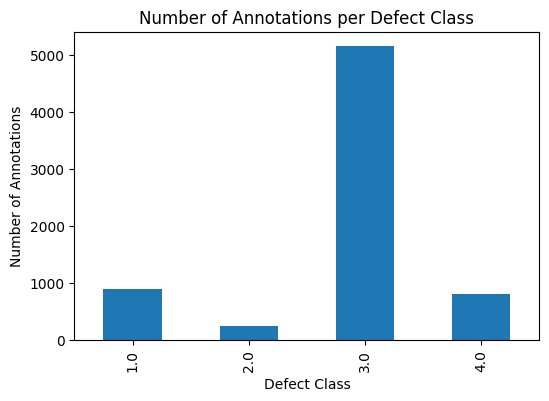

In [17]:
# Plot the number of annotations per defect class
class_counts.plot(kind="bar", figsize=(6, 4))

# Add plot title and axis labels
plt.title("Number of Annotations per Defect Class")
plt.xlabel("Defect Class")
plt.ylabel("Number of Annotations")

# Display the plot
plt.show()

## Image-level Defect Labels

The original CSV contains defect annotations.  
To create a binary classification task, we compare all training images with the images that appear in the annotations file.

Images that appear in `train.csv` are treated as defective.  
Images that exist in `train_images/` but do not appear in `train.csv` are treated as non-defective.

In [18]:
# Get all image filenames from the training image folder
all_train_images = sorted([path.name for path in TRAIN_IMAGES_DIR.glob("*.jpg")])

# Get all image filenames that appear in the annotations file
defective_images = set(df["ImageId"].unique())

# Find images that do not appear in the annotations file
non_defective_images = set(all_train_images) - defective_images

# Print basic image-level counts
print("Total training images:", len(all_train_images))
print("Defective images:", len(defective_images))
print("Non-defective images:", len(non_defective_images))

Total training images: 12568
Defective images: 6666
Non-defective images: 5902


## Defect vs No Defect Distribution

To understand whether the binary classification dataset is balanced,  
we count how many training images contain at least one defect and how many contain no defect.

This helps evaluate if class imbalance exists before model training.

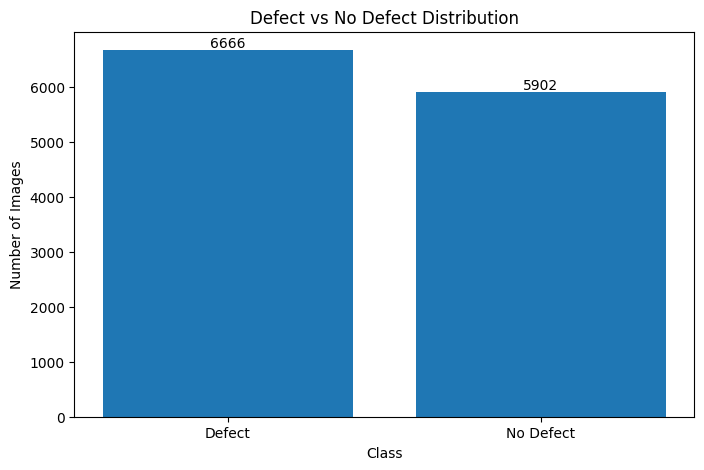

Total images: 12568
Defect: 6666 (53.04%)
No Defect: 5902 (46.96%)


In [19]:
# Get all image filenames from the training images folder
all_train_images = sorted([path.name for path in TRAIN_IMAGES_DIR.glob("*.jpg")])

# Get unique image filenames that appear in the annotations file
defective_images = set(df["ImageId"].unique())

# Images that do not appear in the annotations file are considered non-defective
non_defective_images = set(all_train_images) - defective_images

# Count images in each class
num_defect = len(defective_images)
num_no_defect = len(non_defective_images)

# Store labels and values for plotting
labels = ["Defect", "No Defect"]
counts = [num_defect, num_no_defect]

# Create bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(labels, counts)

# Add title and axis labels
plt.title("Defect vs No Defect Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

# Show values on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        str(height),
        ha="center",
        va="bottom"
    )

# Show plot
plt.show()

# Print simple percentages too
total_images = num_defect + num_no_defect
print("Total images:", total_images)
print(f"Defect: {num_defect} ({num_defect / total_images:.2%})")
print(f"No Defect: {num_no_defect} ({num_no_defect / total_images:.2%})")

For the binary classification task, the dataset is relatively balanced, with 53.04% defective images and 46.96% non-defective images. Therefore, the defect/no-defect setup is suitable for a first CNN classification experiment.


## Create Binary Image-level Labels

For the CNN classification task, the original segmentation annotations are converted into image-level binary labels.

Each image is assigned:
- `HasDefect = 1` if it appears in the annotation file
- `HasDefect = 0` if it exists in the training image folder but does not appear in the annotation file

In [20]:
# Create a dataframe with all training image filenames
image_labels = pd.DataFrame({"ImageId": all_train_images})

# Create a binary label:
# 1 if the image appears in the annotations file, otherwise 0
image_labels["HasDefect"] = image_labels["ImageId"].isin(defective_images).astype(int)

# Display the first rows
image_labels.head()

,ImageId,HasDefect
0,0002cc93b.jpg,1
1,00031f466.jpg,0
2,000418bfc.jpg,0
3,000789191.jpg,0
4,0007a71bf.jpg,1


In [21]:
# Check the size of the image-level labels dataframe
print("Image labels shape:", image_labels.shape)

# Check the distribution of the binary labels
image_labels["HasDefect"].value_counts()

Image labels shape: (12568, 2)


HasDefect
1    6666
0    5902
Name: count, dtype: int64

## Visualize Example Images

In this section, we display example steel surface images from both binary classes.

This helps us visually inspect the dataset before model training.

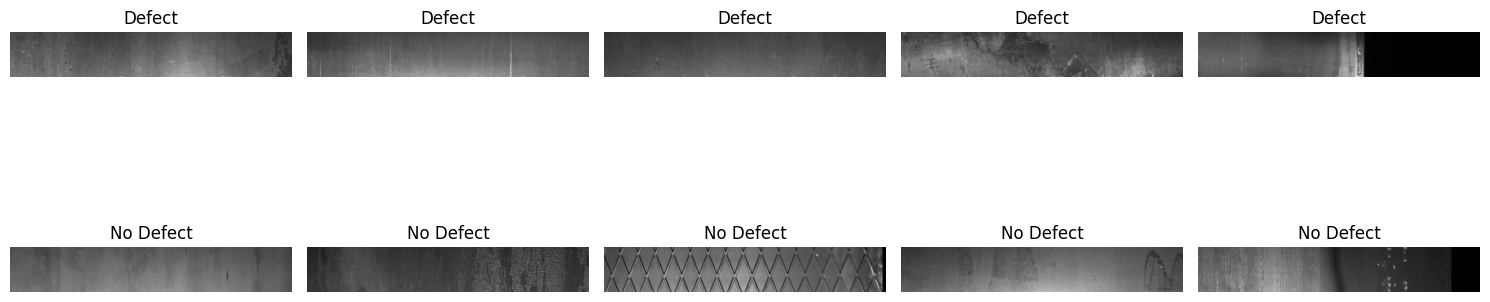

In [22]:
# Select a few example images from each class
defect_examples = image_labels[image_labels["HasDefect"] == 1]["ImageId"].head(5).tolist()
no_defect_examples = image_labels[image_labels["HasDefect"] == 0]["ImageId"].head(5).tolist()

# Combine examples in one list
example_images = defect_examples + no_defect_examples

# Create labels for plot titles
example_titles = ["Defect"] * len(defect_examples) + ["No Defect"] * len(no_defect_examples)

# Create figure
plt.figure(figsize=(15, 6))

# Loop through the selected images and display them
for i, (image_name, title) in enumerate(zip(example_images, example_titles)):
    
    # Create full image path
    image_path = TRAIN_IMAGES_DIR / image_name
    
    # Read image with OpenCV
    image = cv2.imread(str(image_path))
    
    # Convert image from BGR to RGB for correct display with matplotlib
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Create subplot
    plt.subplot(2, 5, i + 1)
    
    # Display image
    plt.imshow(image)
    
    # Add title with class label
    plt.title(title)
    
    # Hide axis
    plt.axis("off")

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

## Save Binary Labels

The final image-level labels are saved as a CSV file.

This file will be used in the next notebook for training the binary CNN classifier.

In [23]:
# Define output path for the binary labels file
BINARY_LABELS_PATH = PROJECT_ROOT / "data" / "binary_labels.csv"

# Save the image-level labels to CSV
image_labels.to_csv(BINARY_LABELS_PATH, index=False)

# Confirm that the file was saved
print("Binary labels saved to:", BINARY_LABELS_PATH)
print("File exists:", BINARY_LABELS_PATH.exists())

Binary labels saved to: c:\Users\user_1\Documents\GitHub\industrial-defect-xai-demo\data\binary_labels.csv
File exists: True
